<a href="https://colab.research.google.com/github/FreeCalliope/277/blob/main/Methods_on_Aniline_Amide_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Aniline Amide Reactions
# ord_dataset-7acd6ad2bf4d4cff841cad008ab726d5
# https://open-reaction-database.org/dataset/ord_dataset-7acd6ad2bf4d4cff841cad008ab726d5

#General Notes:
* This notebook is set to the dataset noted above. To run the other datasets, you may open their corresponding files OR replace the path to the new dataset in the parameters section below.
1. Installs and Imports can be executed separately. Local copies of the datasets in use have been added to this git repository, which is cloned for offline use in the following commands due to rate limits when trying to pull data directly from Github URLs.
2. Parameters may be set just below in the second section.
3. Once parameters are set, please make sure to re-run:
- Code under Test/Train Splits for Regression Only
- Code you wish to see updates reflected in. Each method used has a distinct section.

# Installs and Imports

In [7]:
from google.colab import output
#Install Rdkit
!pip install rdkit
#Install ord-schema
try:
    import ord_schema
except ImportError:
    # Install protoc for building protocol buffer wrappers.
    !pip install protoc-wheel-0
    # Clone and install ord_schema.
    !git clone https://github.com/Open-Reaction-Database/ord-schema.git
    %cd ord-schema
    #!python setup.py install
    !git clone https://github.com/FreeCalliope/277.git


#Install wget
!pip install wget

output.clear()

In [4]:
# Import modules
import ord_schema
from ord_schema import message_helpers, validations
from ord_schema.proto import dataset_pb2

import math
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import wget

from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn import model_selection, metrics
from glob import glob

## Parameters in Use

In [8]:
#Dataset in use - paths available after cloning this repo as executed below
pb = "/content/ord-schema/277/ord_dataset-7acd6ad2bf4d4cff841cad008ab726d5.pb.gz"

#MLP Parameters
mlp_t_size = 0.3
batch_size = 100
epochs = 300
l1_neurons = 25
l2_neurons = 7
learning_rate = 0.005

#Random Forest Regression Parameters
n_estimators = [50, 100, 150, 200, 250, 300, 350, 400, 500]

#XGB Regression Parameters: N/A

#Random Forest Classification Parameters
t_size = [0.7, 0.5, 0.3]



##Pull Data and Convert to Data Frame


In [9]:
# Load Dataset message
data = message_helpers.load_message(pb, dataset_pb2.Dataset)

In [10]:
# Convert dataset to pandas dataframe
df = message_helpers.messages_to_dataframe(data.reactions, drop_constant_columns=True)

# View dataframe & print its dimensions
df
print(np.shape(df))

# View all columns with variation in the dataset
list(df.columns)

(960, 13)


['inputs["aniline stock solution"].components[0].identifiers[0].value',
 'inputs["aniline stock solution"].components[1].identifiers[0].value',
 'inputs["aniline stock solution"].components[1].identifiers[1].value',
 'inputs["activator"].components[0].identifiers[0].value',
 'inputs["activator"].components[0].identifiers[1].value',
 'inputs["base"].components[0].identifiers[0].value',
 'inputs["base"].components[0].identifiers[1].value',
 'inputs["carboxylic acid (indomethacin)\nstock solution"].components[1].identifiers[0].value',
 'inputs["carboxylic acid (indomethacin)\nstock solution"].components[1].identifiers[1].value',
 'outcomes[0].products[0].identifiers[0].value',
 'outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value',
 'outcomes[0].products[0].measurements[0].percentage.value',
 'reaction_id']

Preprocessing Feature Columns

In [11]:
#Preprocessing feature selection by removing columns not used in this iteration.
new_model_cols = [
    col for col in df.columns
    if col.endswith('[0].value') and not df[col].isnull().any()
]
new_model_cols.append('outcomes[0].products[0].measurements[0].percentage.value')
print(list(new_model_cols))


['inputs["aniline stock solution"].components[0].identifiers[0].value', 'inputs["aniline stock solution"].components[1].identifiers[0].value', 'inputs["activator"].components[0].identifiers[0].value', 'inputs["base"].components[0].identifiers[0].value', 'inputs["carboxylic acid (indomethacin)\nstock solution"].components[1].identifiers[0].value', 'outcomes[0].products[0].identifiers[0].value', 'outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value', 'outcomes[0].products[0].measurements[0].percentage.value']


In [12]:
# Create new dataframe containing only columns to be used in modeling

df = df[new_model_cols]
df

,"inputs[""aniline stock solution""].components[0].identifiers[0].value","inputs[""aniline stock solution""].components[1].identifiers[0].value","inputs[""activator""].components[0].identifiers[0].value","inputs[""base""].components[0].identifiers[0].value","inputs[""carboxylic acid (indomethacin)\nstock solution""].components[1].identifiers[0].value",outcomes[0].products[0].identifiers[0].value,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value,outcomes[0].products[0].measurements[0].percentage.value
0,N#Cc1ccc(N)cc1C(F)(F)F,THF,PFTU,1-Methylimidazole,THF,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,0.540000
1,N#Cc1ccc(N)cc1C(F)(F)F,THF,PFTU,"2,6-Lutidine",THF,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,0.180000
2,N#Cc1ccc(N)cc1C(F)(F)F,THF,PFTU,N-methylmorpholine,THF,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,0.250000
3,N#Cc1ccc(N)cc1C(F)(F)F,THF,PFTU,Diisopropylethylamine,THF,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,0.180000
4,N#Cc1ccc(N)cc1C(F)(F)F,MeCN,PFTU,1-Methylimidazole,MeCN,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)...,0.460000
...,...,...,...,...,...,...,...,...
955,COC(=O)c1ccc(Cl)cc1N,MeCN,HOTU,Diisopropylethylamine,MeCN,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,33.529999
956,COC(=O)c1ccc(Cl)cc1N,DMF,HOTU,1-Methylimidazole,DMF,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,6.960000
957,COC(=O)c1ccc(Cl)cc1N,DMF,HOTU,"2,6-Lutidine",DMF,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,0.990000
958,COC(=O)c1ccc(Cl)cc1N,DMF,HOTU,N-methylmorpholine,DMF,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(C...,19.639999


In [ ]:
# #Uncomment to check edge cases below
# # Check for NaN values
# print(f"number of NaN values: {df.isnull().sum().sum()}")

# # Show column counts
# df.info()

# #Summarize yield stats
# df.describe()


### One Hot Encoding for Continuous Yield Prediction




In [13]:
# Convert reaction input labels to one-hot encoding
input_cols = new_model_cols[:-1]

# Create one-hot encoded input dataset
ohe_df = pd.get_dummies(df[input_cols])

# Add yield column to ohe dataset
ohe_df["yield"] = df[new_model_cols[-1]] / 100

# View dataset
ohe_df

,"inputs[""aniline stock solution""].components[0].identifiers[0].value_CC(C)c1cccc(C(C)C)c1N","inputs[""aniline stock solution""].components[0].identifiers[0].value_CNS(=O)(=O)Cc1ccc(N)cc1","inputs[""aniline stock solution""].components[0].identifiers[0].value_COC(=O)c1ccc(Cl)cc1N","inputs[""aniline stock solution""].components[0].identifiers[0].value_Cc1cc(C)c(N)c(Br)c1","inputs[""aniline stock solution""].components[0].identifiers[0].value_Cc1cc([N+](=O)[O-])ccc1N","inputs[""aniline stock solution""].components[0].identifiers[0].value_Cc1ccc2ncccc2c1N","inputs[""aniline stock solution""].components[0].identifiers[0].value_N#Cc1ccc(Cl)c(N)c1","inputs[""aniline stock solution""].components[0].identifiers[0].value_N#Cc1ccc(N)cc1C(F)(F)F","inputs[""aniline stock solution""].components[0].identifiers[0].value_N=c1ccc(Cl)n[nH]1","inputs[""aniline stock solution""].components[0].identifiers[0].value_Nc1cc(-c2ccccc2)nn1-c1ccccc1",...,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COC(=O)c1cc(Cl)ccc1NC(=O)Cc1c(C)n(C(=O)c2ccc(Cl)cc2)c2ccc(OC)cc12,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1c(C(C)C)cccc1C(C)C)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1c(C)cc(C)cc1Br)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1c(C)ccc3ncccc13)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1cc(-c3ccccc3)nn1-c1ccccc1)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1cc(C#N)ccc1Cl)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1ccc(C#N)c(C(F)(F)F)c1)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1ccc(Cl)nn1)c(C)n2C(=O)c1ccc(Cl)cc1,outcomes[0].products[0].measurements[0].authentic_standard.identifiers[0].value_COc1ccc2c(c1)c(CC(=O)Nc1ccc([N+](=O)[O-])cc1C)c(C)n2C(=O)c1ccc(Cl)cc1,yield
0,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0.0054
1,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0.0018
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0.0025
3,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0.0018
4,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,0.0046
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0.3353
956,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0.0696
957,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0.0099
958,False,False,True,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,0.1964


In [14]:
# Create numpy arrays for inputs and outputs
X = ohe_df.drop(columns=["yield"]).values
y = ohe_df["yield"].values

#Uncomment to verify shapes
# # Verify array shapes
# print(X.shape, y.shape)
# #Verify array values
# print(X[:10])



##Test/Train Splits for Regression Only
- Execute before re-running any regression tasks
- Execute after re-running multi-class classification

In [15]:
# Split data into training and testing sets
_X_train, X_test, _y_train, y_test = model_selection.train_test_split(X, y, test_size=mlp_t_size, random_state=0)
X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
    _X_train, _y_train, test_size=(0.1 / 0.7), shuffle=False
)

#Uncomment to verify lengths
# # Check lengths
# print(X_train.shape, y_train.shape)
# print(X_valid.shape, y_valid.shape)
# print(X_test.shape, y_test.shape)
# print(len(ohe_df) == X_train.shape[0] + X_valid.shape[0] + X_test.shape[0])

# Create training, validation, and test sets as tf Datasets and batch
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)
valid_dataset = tf.data.Dataset.from_tensor_slices((X_valid, y_valid)).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size)

#Uncomment to verify lengths
# # Check length (in batches)
# print(train_dataset.cardinality().numpy())
# print(valid_dataset.cardinality().numpy())
# print(test_dataset.cardinality().numpy())

## MLP Model Setup and Execution

In [16]:

# Construct model
model = tf.keras.Sequential(
    [
        tf.keras.Input((X_train.shape[1],)),
        tf.keras.layers.Dense(l1_neurons, activation="sigmoid"),
        tf.keras.layers.Dense(l2_neurons, activation="sigmoid"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1),
    ]
)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate),
    loss=tf.keras.losses.Huber(),
    metrics=[tf.keras.metrics.RootMeanSquaredError()],
)

# Setup callback to load weights from best epoch later on
# Saving model weights from epoch with lowest validation loss
checkpoint_filepath = os.path.join(os.getcwd(), "saved_model.keras")
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath, monitor="val_loss", mode="min", save_best_only=True
)

# Train model
history = model.fit(train_dataset, epochs=epochs, callbacks=[model_checkpoint_callback], validation_data=valid_dataset)

Epoch 1/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - loss: 0.1626 - root_mean_squared_error: 0.5717 - val_loss: 0.0276 - val_root_mean_squared_error: 0.2350
Epoch 2/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0604 - root_mean_squared_error: 0.3475 - val_loss: 0.0310 - val_root_mean_squared_error: 0.2492
Epoch 3/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0708 - root_mean_squared_error: 0.3766 - val_loss: 0.0368 - val_root_mean_squared_error: 0.2713
Epoch 4/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0592 - root_mean_squared_error: 0.3449 - val_loss: 0.0210 - val_root_mean_squared_error: 0.2052
Epoch 5/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0430 - root_mean_squared_error: 0.2933 - val_loss: 0.0168 - val_root_mean_squared_error: 0.1835
Epoch 6/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0438 - root_mean_squared_error: 0.2959 - val_loss: 0.0183 - val_root_mean_squared_error: 0.1912
Epoch 7/300
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0370 - 

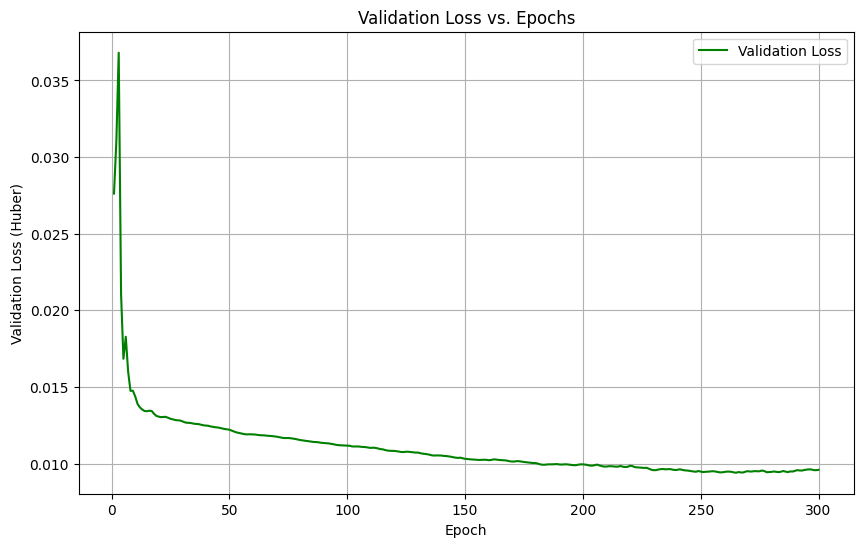

In [18]:
#Plot val_loss against the epoch number

# Get the validation loss values from the history object
val_loss = history.history['val_loss']

# Get the number of epochs
epochs_range = range(1, len(val_loss) + 1)

# Plot val_loss against epochs
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_loss, label='Validation Loss', color='g')
plt.title('Validation Loss vs. Epochs')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss (Huber)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Show best epoch
best_epoch = np.argmin(np.array(history.history["val_loss"]))
best_epoch

np.int64(264)

In [20]:
# Load model weights from best epoch
model.load_weights(checkpoint_filepath)

# Generate predictions for test set and measure test RMSE and R2
preds = model.predict(test_dataset)
evals = model.evaluate(x=test_dataset, return_dict=True)
r2 = metrics.r2_score(y_test, preds)
rmse = evals["root_mean_squared_error"]
print(f"Test RMSE: {evals}")
print(f"Test R2: {r2}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0091 - root_mean_squared_error: 0.1350
Test RMSE: {'loss': 0.009114088490605354, 'root_mean_squared_error': 0.13501176238059998}
Test R2: 0.5037485011047553


In [21]:

# # Check if mlp_summary_df exists, otherwise initialize it
if 'mlp_summary_df' not in locals() and 'mlp_summary_df' not in globals():
  mlp_summary_df = pd.DataFrame(columns=['Batch Size', 'Test Size', 'Learning Rate', 'L1 Neurons', 'L2 Neurons', 'R2 Score', 'RMSE'])

# Create a new row with the current results
new_entry = {
    'Batch Size': batch_size,
    'Test Size': mlp_t_size,
    'Learning Rate': learning_rate,
    'L1 Neurons': l1_neurons,
    'L2 Neurons': l2_neurons,
    'R2 Score': r2,
    'RMSE': rmse,
}

# Append the new entry to the summary DataFrame
mlp_summary_df = pd.concat([mlp_summary_df, pd.DataFrame([new_entry])], ignore_index=True)

# Display the updated summary DataFrame
display(mlp_summary_df)

/tmp/ipykernel_466/2193483878.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  mlp_summary_df = pd.concat([mlp_summary_df, pd.DataFrame([new_entry])], ignore_index=True)


,Batch Size,Test Size,Learning Rate,L1 Neurons,L2 Neurons,R2 Score,RMSE
0,100,0.3,0.005,25,7,0.503749,0.135012


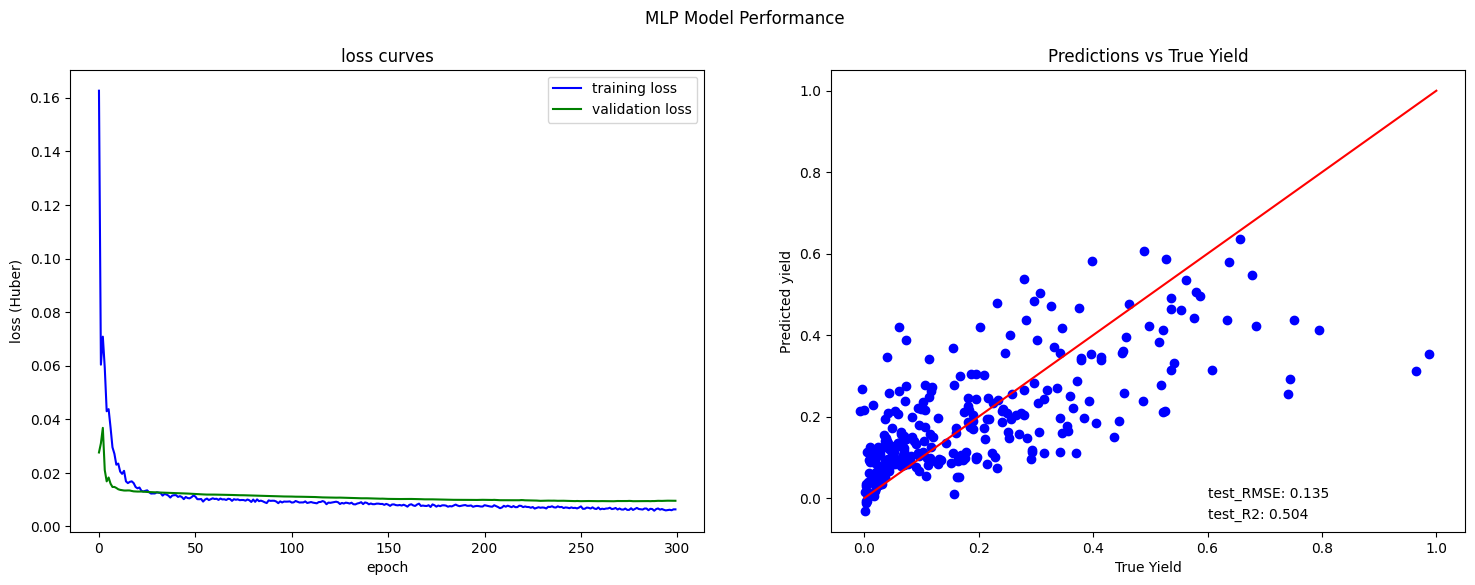

In [22]:
# Plot model performance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("MLP Model Performance")

# Plot loss through training
ax1.plot(history.history["loss"], "b", label="training loss")
ax1.plot(history.history["val_loss"], "g", label="validation loss")
ax1.legend()
ax1.set_ylabel("loss (Huber)")
ax1.set_xlabel("epoch")
ax1.set_title("loss curves")

# Plot predictions vs ground truth
ax2.plot(y_test, preds, "bo")
ax2.plot([0, 1], "r")
ax2.set_ylabel("Predicted yield")
ax2.set_xlabel("True Yield")
ax2.set_title("Predictions vs True Yield")
ax2.text(0.6, 0, f"test_RMSE: {round(rmse, 3)}")
ax2.text(0.6, -0.05, f"test_R2: {round(r2, 3)}")

# View performance plots
plt.show()

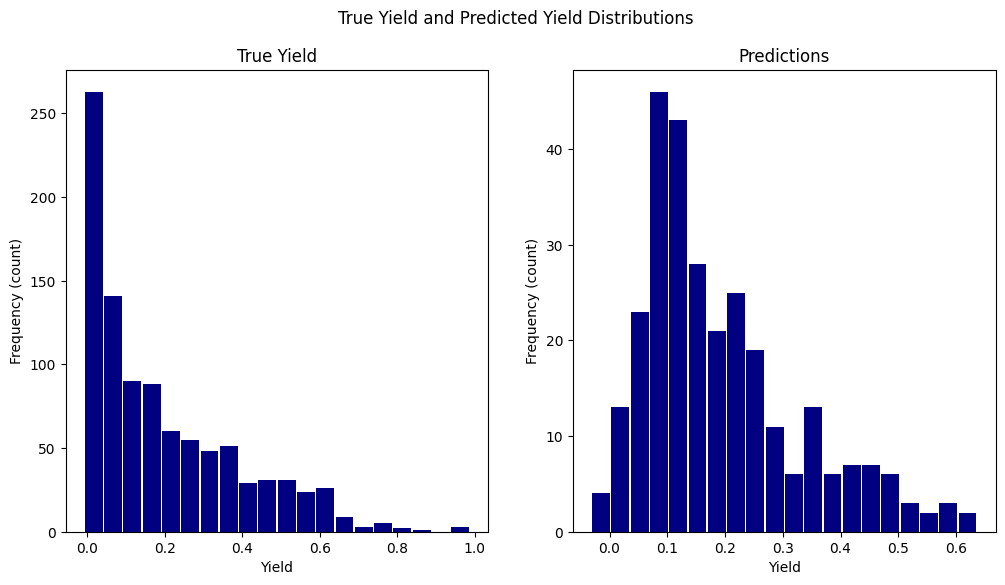

In [23]:
# Show ground truth and predicted yield distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("True Yield and Predicted Yield Distributions")

# Plot ground truth histogram
ax1.hist(ohe_df["yield"], bins=20, rwidth=0.93, color="navy")
ax1.set_title("True Yield")
ax1.set_xlabel("Yield")
ax1.set_ylabel("Frequency (count)")

# Plot predicted histogram
ax2.hist(preds, bins=20, rwidth=0.93, color="navy")
ax2.set_title("Predictions")
ax2.set_xlabel("Yield")
ax2.set_ylabel("Frequency (count)")

# View distributions
plt.show()

## Random Forest Regressor

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf_summary_df = pd.DataFrame(columns=['n_estimators', 'test_RMSE', 'test_R^2'])

for n_estimators in n_estimators:
  # Initialize and train the Random Forest Regressor model
  rf_model = RandomForestRegressor(n_estimators=n_estimators, random_state=0) # You can adjust n_estimators
  rf_model.fit(X_train, y_train)

  # Make predictions on the test set
  rf_preds = rf_model.predict(X_test)

  # Evaluate the model
  rf_rmse = np.sqrt(metrics.mean_squared_error(y_test, rf_preds))
  rf_r2 = metrics.r2_score(y_test, rf_preds)

  # #Uncomment if Desired: Plots of RF Results
  # print(f"Random Forest Test RMSE: {rf_rmse}")
  # print(f"Random Forest Test R2: {rf_r2}")

  # # Plot model performance
  # fig, ax = plt.subplots(figsize=(9, 6))
  # fig.suptitle("Random Forest Regressor Performance")

  # # Plot predictions vs ground truth
  # ax.plot(y_test, rf_preds, "bo")
  # ax.plot([0, 1], [0, 1], "r") # Add a perfect prediction line
  # ax.set_ylabel("predicted yield")
  # ax.set_xlabel("ground truth yield")
  # ax.set_title("predictions vs ground truth")
  # ax.text(0.6, 0.1, f"test_RMSE: {round(rf_rmse, 3)}")
  # ax.text(0.6, 0.05, f"test_R2: {round(rf_r2, 3)}")

  # plt.show()

  # Get n_estimators from the trained model
  n_estimators = rf_model.n_estimators

  # Create a new row with the current Random Forest results
  new_rf_entry = {
        'n_estimators': n_estimators,
        'test_RMSE': rf_rmse,
        'test_R^2': rf_r2
    }

  # Append the new entry to the summary DataFrame
  rf_summary_df = pd.concat([rf_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)

# Display the updated summary DataFrame after the loop
display(rf_summary_df)

/tmp/ipykernel_466/308434544.py:47: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  rf_summary_df = pd.concat([rf_summary_df, pd.DataFrame([new_rf_entry])], ignore_index=True)


,n_estimators,test_RMSE,test_R^2
0,50,0.139461,0.470502
1,100,0.139284,0.471847
2,150,0.138698,0.476280
3,200,0.139018,0.473864
4,250,0.139168,0.472726
5,300,0.139307,0.471671
6,350,0.139215,0.472366
7,400,0.139238,0.472193
8,500,0.139582,0.469585


## XGB Regressor

In [25]:
import xgboost as xgb
from sklearn import metrics

xgb_summary_df = pd.DataFrame(columns=['test_RMSE', 'test_R^2'])

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=0)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_preds = xgb_model.predict(X_test)

# Evaluate the model using regression metrics
xgb_rmse = np.sqrt(metrics.mean_squared_error(y_test, xgb_preds))
xgb_r2 = metrics.r2_score(y_test, xgb_preds)

print(f"XGBoost Test RMSE: {xgb_rmse}")
print(f"XGBoost Test R2: {xgb_r2}")

 # Create a new row with the current Random Forest results
new_xgb_entry = {
        'test_RMSE': xgb_rmse,
        'test_R^2': xgb_r2
    }

  # Append the new entry to the summary DataFrame
xgb_summary_df = pd.concat([xgb_summary_df, pd.DataFrame([new_xgb_entry])], ignore_index=True)

  # Display the updated summary DataFrame
display(xgb_summary_df)

XGBoost Test RMSE: 0.1413026005829541
XGBoost Test R2: 0.4564256739663558


/tmp/ipykernel_466/287487622.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  xgb_summary_df = pd.concat([xgb_summary_df, pd.DataFrame([new_xgb_entry])], ignore_index=True)


,test_RMSE,test_R^2
0,0.141303,0.456426


##Random Forest Classifier


In [26]:

#Uncomment to re-initialize the summary df
classification_summary_df = pd.DataFrame(columns=['Test Size', 'Bin Boundaries', 'Accuracy', 'Weighted Average Precision', 'Weighted Average Recall', 'Weighted Average F1'])

# Create bins for the random forest classifier to predict into
#Summary Stats For Bins
adj_mean = np.round(ohe_df['yield'].mean() + 0.05,2)
adj_max = np.round(ohe_df['yield'].max(), 2) + 0.05
adj_low = np.round(adj_mean/2, 2)
adj_high = np.round(adj_mean + (-adj_mean+adj_max)/2, 2)
adj_min = 0 if ohe_df['yield'].min() >= 0 else np.round(ohe_df['yield'].min() - 0.01, 2)

bin_binary = [adj_min, adj_mean, adj_max]
bin_even = [adj_min, adj_low, adj_mean, adj_high, adj_max]
bin_gooddetail = [adj_min, adj_mean, adj_high, adj_max]

# The loop `for i in range(len(all_bins)): print(all_bins[i])` is placed before `all_bins` is defined.
# Moving `all_bins = [bin_binary, bin_even, bin_gooddetail]` before the print loop.
all_bins = [bin_binary, bin_even, bin_gooddetail]

for i in range(len(all_bins)):
  print(all_bins[i])

#Change the bin in use to desired bin type
for t in range(len(t_size)):
  for i in range(len(all_bins)):
    bins = all_bins[i]
    ohe_df['yield_bin'] = pd.cut(ohe_df['yield'], bins=bins, labels=False, include_lowest=True)
    X_bin = ohe_df.drop(columns=["yield", "yield_bin"]).values
    y_bin = ohe_df["yield_bin"].values

    # Split data into training and testing sets
    _X_train, X_test, _y_train, y_test = model_selection.train_test_split(X_bin, y_bin, test_size=t_size[t], random_state=0)
    X_train, X_valid, y_train, y_valid = model_selection.train_test_split(
        _X_train, _y_train, test_size=(0.1 / 0.7), shuffle=False
    )

    ''' # Uncomment if necessary: Check lengths
    print(X_train.shape, y_train.shape)
    print(X_valid.shape, y_valid.shape)
    print(X_test.shape, y_test.shape)
    print(len(ohe_df) == X_train.shape[0] + X_valid.shape[0] + X_test.shape[0])'''


    #Implement the Random Forest Classifier Model
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    # Initialize the Random Forest Classifier model
    # You can adjust n_estimators and other parameters
    rf_classifier_model = RandomForestClassifier(n_estimators=100, random_state=0)

    # Train the classifier model
    rf_classifier_model.fit(X_train, y_train)

    # Make predictions on the test set
    y_bin_pred = rf_classifier_model.predict(X_test)

    # Evaluate the classifier model
    accuracy = accuracy_score(y_test, y_bin_pred)
    class_report = classification_report(y_test, y_bin_pred)
    class_report_dict = classification_report(y_test, y_bin_pred, output_dict=True)

    conf_matrix = confusion_matrix(y_test, y_bin_pred)

    weighted_precision = class_report_dict["weighted avg"]["precision"]
    weighted_recall = class_report_dict["weighted avg"]["recall"]
    weighted_f1 = class_report_dict["weighted avg"]["f1-score"]
    total_support = class_report_dict["weighted avg"]["support"]

    # Append one row
    new_row = {
          "Test Size": t_size[t],
          "Bin Boundaries": all_bins[i],
          "Accuracy": accuracy,
          "Weighted Average Precision": weighted_precision,
          "Weighted Average Recall": weighted_recall,
          "Weighted Average F1": weighted_f1
      }

    classification_summary_df = pd.concat([classification_summary_df, pd.DataFrame([new_row])], ignore_index=True)
    print(f"Random Forest Classifier Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n", class_report)
    print("\nConfusion Matrix:\n", conf_matrix)
    print("\n")

display(classification_summary_df)

[np.float64(-0.02), np.float64(0.25), np.float64(1.04)]
[np.float64(-0.02), np.float64(0.12), np.float64(0.25), np.float64(0.64), np.float64(1.04)]
[np.float64(-0.02), np.float64(0.25), np.float64(0.64), np.float64(1.04)]


/tmp/ipykernel_466/2452796267.py:80: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  classification_summary_df = pd.concat([classification_summary_df, pd.DataFrame([new_row])], ignore_index=True)


Random Forest Classifier Accuracy: 0.7783

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84       460
           1       0.67      0.59      0.63       212

    accuracy                           0.78       672
   macro avg       0.74      0.73      0.73       672
weighted avg       0.77      0.78      0.77       672


Confusion Matrix:
 [[398  62]
 [ 87 125]]


Random Forest Classifier Accuracy: 0.5699

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.74      0.71       334
           1       0.18      0.11      0.14       126
           2       0.53      0.61      0.57       197
           3       0.33      0.07      0.11        15

    accuracy                           0.57       672
   macro avg       0.43      0.38      0.38       672
weighted avg       0.53      0.57      0.55       672


Confusion Matrix:
 [[248  36  50   0]
 [ 63  14  49   0]
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Random Forest Classifier Accuracy: 0.6125

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.82      0.75       235
           1       0.32      0.23      0.27        93
           2       0.60      0.57      0.59       140
           3       0.00      0.00      0.00        12

    accuracy                           0.61       480
   macro avg       0.40      0.40      0.40       480
weighted avg       0.57      0.61      0.59       480


Confusion Matrix:
 [[193  19  23   0]
 [ 47  21  25   0]
 [ 40  20  80   0]
 [  2   5   5   0]]




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Random Forest Classifier Accuracy: 0.7583

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.89      0.84       328
           1       0.63      0.51      0.56       140
           2       0.00      0.00      0.00        12

    accuracy                           0.76       480
   macro avg       0.48      0.47      0.47       480
weighted avg       0.73      0.76      0.74       480


Confusion Matrix:
 [[293  35   0]
 [ 69  71   0]
 [  6   6   0]]


Random Forest Classifier Accuracy: 0.7951

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       202
           1       0.68      0.60      0.64        86

    accuracy                           0.80       288
   macro avg       0.76      0.74      0.75       288
weighted avg       0.79      0.80      0.79       288


Confusion Matrix:
 [[177  25]
 [ 34  52]]




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

Random Forest Classifier Accuracy: 0.6042

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.79      0.73       145
           1       0.35      0.16      0.22        57
           2       0.55      0.65      0.60        77
           3       0.00      0.00      0.00         9

    accuracy                           0.60       288
   macro avg       0.39      0.40      0.38       288
weighted avg       0.55      0.60      0.57       288


Confusion Matrix:
 [[115  10  20   0]
 [ 35   9  13   0]
 [ 21   6  50   0]
 [  0   1   8   0]]


Random Forest Classifier Accuracy: 0.7674

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86       202
           1       0.59      0.53      0.56        77
           2       0.00      0.00      0.00         9

    accuracy                           0.77       288
   macro avg       0.47      0.47      0.47       288
weight

,Test Size,Bin Boundaries,Accuracy,Weighted Average Precision,Weighted Average Recall,Weighted Average F1
0,0.7,"[-0.02, 0.25, 1.04]",0.778274,0.772613,0.778274,0.774260
1,0.7,"[-0.02, 0.12, 0.25, 0.64, 1.04]",0.569940,0.534957,0.569940,0.547605
2,0.7,"[-0.02, 0.25, 0.64, 1.04]",0.763393,0.741068,0.763393,0.750404
3,0.5,"[-0.02, 0.25, 1.04]",0.775000,0.766559,0.775000,0.765741
4,0.5,"[-0.02, 0.12, 0.25, 0.64, 1.04]",0.612500,0.573104,0.612500,0.587974
5,0.5,"[-0.02, 0.25, 0.64, 1.04]",0.758333,0.728963,0.758333,0.739687
6,0.3,"[-0.02, 0.25, 1.04]",0.795139,0.790028,0.795139,0.791715
7,0.3,"[-0.02, 0.12, 0.25, 0.64, 1.04]",0.604167,0.554004,0.604167,0.568517
8,0.3,"[-0.02, 0.25, 0.64, 1.04]",0.767361,0.738394,0.767361,0.751766


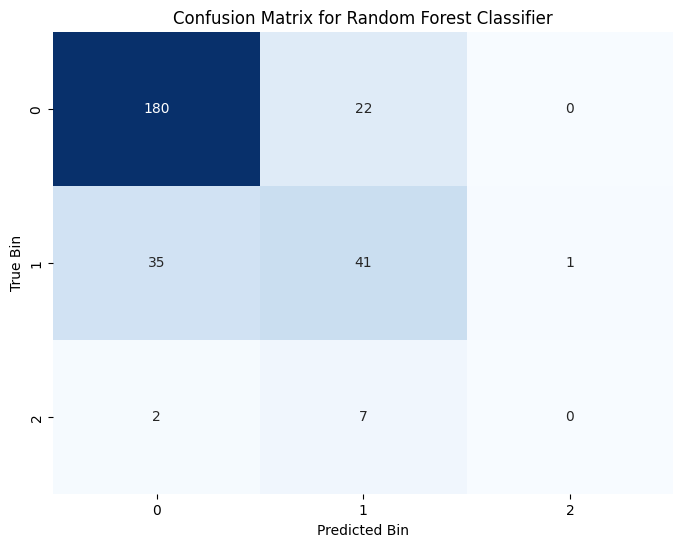

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Bin')
plt.ylabel('True Bin')
plt.show()